**PROJECT TITLE**

Real-world Data Cleaning & Preprocessing Pipeline

**OBJECTIVE**

Clean messey datasets and transform them into a realiable ,analysis-ready format



In [3]:
#load the data use python with pandas and numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/AB_NYC_2019.csv")
print(df.shape)
df.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0


In [2]:
# Tocheck Data Integrity Check
# we have to check data types wrong values like age and invalid entries , inconsistent catgories

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
#handle missing data
#like remove rows fill with median mode mean forward and backward fill

df['reviews_per_month'].fillna(df['reviews_per_month'].mean(),inplace=True)

/tmp/ipykernel_9099/1467823790.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(df['reviews_per_month'].mean(),inplace=True)


In [8]:
#remove duplicates

df.drop_duplicates(inplace=True)

In [11]:
#standardization
# to fix date formates text case and units

df['name'] = df['name'].str.lower()

In [24]:
#outliers detection
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR= Q3 - Q1


Exploring missing values

In [4]:
print(df.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


Explore missing values

In [7]:
df['name'].fillna('unknown',inplace=True)
df['host_name'].fillna('unknown',inplace=True)
df['reviews_per_month'].fillna(0,inplace=True)
df['last_review'].fillna('No reviw',inplace=True)


/tmp/ipykernel_5548/2504820681.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0,inplace=True)
/tmp/ipykernel_5548/2504820681.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Check duplicates

In [8]:
print("Duplicates:",df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates: 0


Outlier detection in price


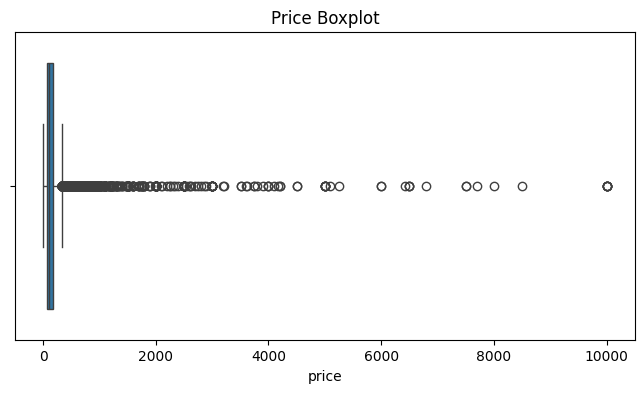

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x = df['price'])
plt.title('Price Boxplot')
plt.show()

Remove outliers


In [11]:
df = df[df['price'] < 10000]
df = df[df['price'] > 0]
print(f"shape after removing outliers: {df.shape}")

shape after removing outliers: (48881, 16)


Standardize room_type

In [12]:
print(df['room_type'].value_counts())
df['room_type'] = df['room_type'].str.strip().str.title()


room_type
Entire home/apt    25405
Private room       22318
Shared room         1158
Name: count, dtype: int64


Verified cleaned data

In [13]:
print("Missing values after cleaning")
print(df.isnull().sum())
print("\nFinal shape:" , df.shape)

Missing values after cleaning
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Final shape: (48881, 16)


Visualization


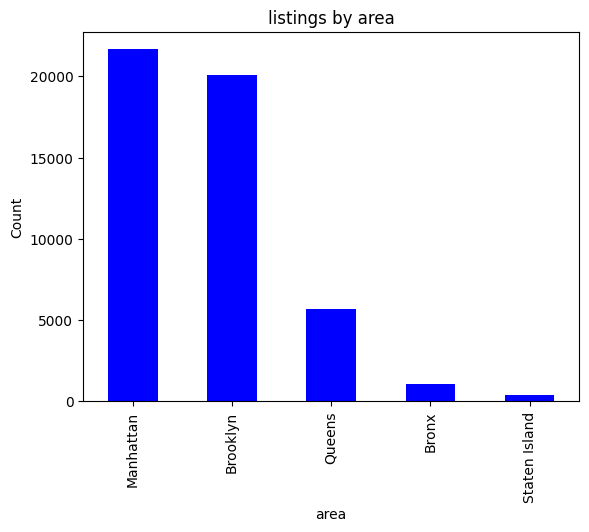

In [16]:
df['neighbourhood_group'].value_counts().plot(kind ='bar', color = "Blue")
plt .title('listings by area')
plt.xlabel('area')
plt.ylabel('Count')
plt.show()

Data Cleaning Observations

- Dataset had 48,895 rows and 16 columns
- Missing values found in name, host_name, last_review, reviews_per_month
- Filled missing text columns with 'Unknown'
- Filled missing reviews_per_month with 0
- Removed price outliers above 10,000 and equal to 0
- No duplicate rows found
- Data is now clean and ready for analysis